In [172]:
from IPython.display import clear_output
import time
from time import sleep
import sys
import urllib.request
from bs4 import BeautifulSoup
import re
import pandas as pd
import myrace as mrc

""" 出走表の取得 """
rc = mrc.Rcd("阪神sun")
race = rc.grc() + "11"

race_url="https://race.netkeiba.com/?pid=race_old&id=c2019" + race + "&mode=top"

req = urllib.request.Request(race_url)
try:
    urllib.request.urlopen(req)
except urllib.error.URLError as e:
    print(e.reason)
    sys.exit()

cal_html = urllib.request.urlopen(race_url)
print("response: ", cal_html.getcode(), end=" ")
sleep(1)
clear_output()

cal_soup = BeautifulSoup(cal_html,"lxml")
cal_df = pd.io.html.read_html(cal_soup.prettify())

""" レース名 """
title_soup = cal_soup.find("dl", class_="racedata fc")
race_title = rc.nrc() + " " +  re.sub("\n", "", title_soup.find("dt").text)
race_title += " " +  re.sub("\xa0", "", title_soup.find("h1").text)
race_title += " " + re.sub("\xa0", "", title_soup.find_all("p")[0].text)
print(race_title)
df = cal_df[0]
df.columns = df.columns.droplevel()
df

阪神 11R ポートアイランドＳ 芝1600m(右 外)


,枠 番,馬 番,馬名,性齢,負担 重量,騎手,厩舎,馬体重,単勝 オッズ,人 気
0,1,1,ロードマイウェイ,牡3,54.0,吉田隼,杉山,NaN,4.1,2
1,2,2,マイネルフラップ,牡3,54.0,和田,梅田,NaN,11.6,6
2,2,3,キョウヘイ,牡5,56.0,高倉,宮本,NaN,17.9,7
3,3,4,ボールライトニング,牡6,56.0,中谷,宮本,NaN,53.9,14
4,3,5,サフランハート,牡6,56.0,池添,北出,NaN,38.2,10
5,4,6,シャイニービーム,牡7,56.0,藤井勘,羽月,NaN,31.9,9
6,4,7,アマルフィコースト,牝4,54.0,坂井,牧田,NaN,7.4,3
7,5,8,クラウンディバイダ,セ6,56.0,国分恭,天間,NaN,207.5,15
8,5,9,メイショウオワラ,牝5,54.0,Ｍデムーロ,岡田,NaN,8.2,4
9,6,10,サトノアーサー,牡5,57.0,松山,池江,NaN,3.2,1


In [173]:
""" 対象レースの距離 """
c_distance = re.sub("\xa0", "", title_soup.find_all("p")[0].text)
c_distance = re.sub("[m()右左]", "", c_distance)

class Horse:
    """ １レース内の競走馬クラス """
    def __init__(self, number, name, jockey, records):
        self.number = number
        self.name = name
        self.jockey = jockey
        self.records = records
    
    def get_number(self):
        return self.number
        
    def get_name(self):
        return self.name
    
    def get_jockey(self):
        return self.jockey
    
    def get_records(self):
        return self.records
    
    def get_distances(self):
        distances = []
        for i in range(len(self.records)):
            distance = self.records[i][0]
            distances.append(int(distance[1:]))
        return distances
    
    def get_times(self):
        times = []
        for i in range(len(self.records)):
            time = self.records[i][1]
            times.append(float(time.split(":")[0])*60 + float(time.split(":")[1]))
        return times
            
    
entries_soup = cal_soup.find_all("td", class_="txt_l horsename")
horse_links = [entries_soup[i].find("a").get("href") for i in range(len(df))]

numbers = [n for n in df['馬  番']]
horse_names = [h for h in df.馬名]
jockeys = [j for j in df.騎手]

records = []
for i in range(len(df)):
    horse_html = urllib.request.urlopen(horse_links[i])
    print("response: ", horse_html.getcode())
    sleep(0.5)
    clear_output()
    horse_soup = BeautifulSoup(horse_html,"lxml")
    horse_df = pd.io.html.read_html(horse_soup.prettify())
    if(len(horse_df)>3 and horse_df[3].columns[0] == '日付'):
        record_df = horse_df[3]
        distances = record_df['距離']
        times = record_df['タイム']
        record = [[d, t] for d, t in zip(distances, times) if type(t) != float] # nan削除
        records.append(record)
    else:
        record = []
        records.append([])

horses = []
for i in range(len(df)):
    horses.append(Horse(numbers[i], horse_names[i], jockeys[i], records[i]))

print("Created a horses object list")

Created a horses object list


In [174]:
print(race_title)
total_distance = 0
total_time = 0
speeds = []
for i in range(len(horses)):
    total_distance = sum(horses[i].get_distances())
    total_time = sum(horses[i].get_times())
    speeds.append(total_distance/total_time)

阪神 11R ポートアイランドＳ 芝1600m(右 外)


In [175]:
numbers = [horses[i].get_number() for i in range(len(horses))]
names = [horses[i].get_name() for i in range(len(horses))]
jockeys = [horses[i].get_jockey() for i in range(len(horses))]
s_df = pd.DataFrame({
    '馬番': pd.Series(numbers),
    '馬名': pd.Series(names),
    '旗手': pd.Series(jockeys),
    '速度': pd.Series(speeds)
})
r_df = s_df.sort_values('速度', ascending=False)
ani_df = r_df.reset_index()
ani_df

,index,馬番,馬名,旗手,速度
0,6,7,アマルフィコースト,坂井,17.183664
1,4,5,サフランハート,池添,17.035158
2,10,11,ストーミーシー,江田照,17.015084
3,3,4,ボールライトニング,中谷,16.869815
4,2,3,キョウヘイ,高倉,16.803557
5,8,9,メイショウオワラ,Ｍデムーロ,16.746960
6,0,1,ロードマイウェイ,吉田隼,16.744409
7,14,15,アーバンキッド,横山武,16.691762
8,1,2,マイネルフラップ,和田,16.651620
9,12,13,アドマイヤアルバ,北村友,16.629357


In [158]:
int(ani_df['速度'][8])

16

<IPython.core.display.Javascript object>


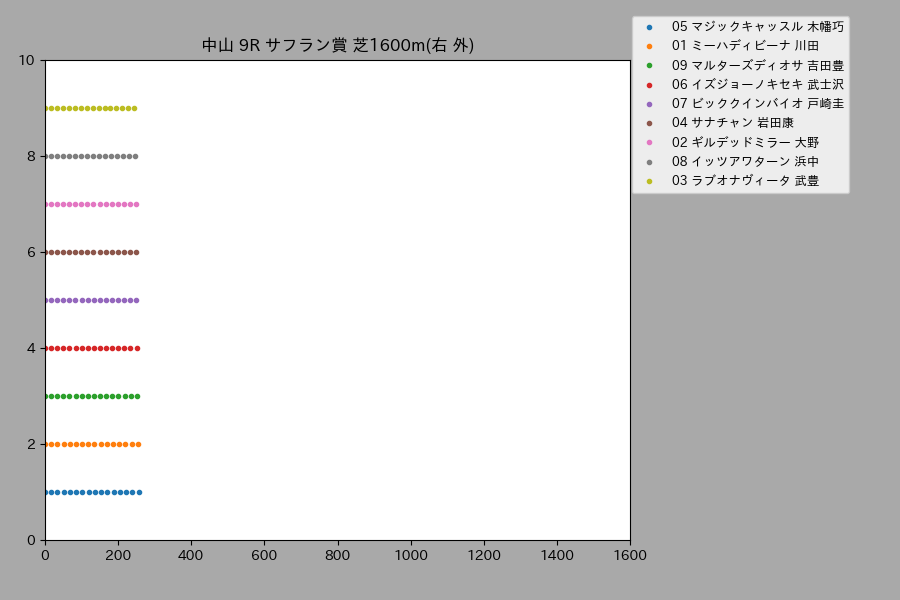

In [157]:
import matplotlib.pyplot as plt
%matplotlib nbagg
from matplotlib import animation

class ani_horses:
    """
    競走馬のクラス
    """
    def __init__(self, arrival, umaban, name, speed, max_time):
        self.arrival = arrival
        self.umaban = umaban
        self.name = name
        self.speed = speed
        self.max_time = max_time
    
    def x_val(self):
        x = [self.speed * i for i in range(max_time)]
        return x
    
    def y_val(self):
        y = [self.arrival for _ in range(max_time)]
        return y
    
    def name(self):
        return self.name

distance = re.sub("\xa0", "", cal_soup.find("dl", class_="racedata fc").find("p").text)
distance = int(re.sub("\\D", "", distance))

# time_lst =[]
# for t in df['タイム']:
#     time_lst.append(float(t.split(":")[0])*60 + float(t.split(":")[1]))

# max_time = int(np.ceil(min(time_lst))) # frame割を最速タイム np.ceil 実数->整数
max_time = int(ani_df['速度'][8])
hrs = []
for i in range(len(ani_df)):
    hrs.append(ani_horses(i+1, ani_df['馬番'][i], ani_df['馬名'][i], ani_df['速度'][i], max_time))

fig = plt.figure(figsize=(9, 6), facecolor="#a9a9a9")

line = []
for h in range(len(hrs)):
    lbl = str(hrs[h].umaban).rjust(2,"0") + " " + hrs[h].name + " " + df['騎手'][h]
    data, = plt.plot(hrs[h].x_val()[h], hrs[h].y_val()[h], '.', label=lbl)
    line.append(data)

def update(i):
    for h in range(len(hrs)):
        line[h].set_data(hrs[h].x_val()[:i], hrs[h].y_val()[:i])
    
ani = animation.FuncAnimation(fig, update, interval=10, frames=distance)

plt.xlim([hrs[0].x_val()[0], distance])
plt.ylim([0, len(df)+1])
plt.rcParams["font.family"] = "IPAexGothic"
plt.title(race_title)
plt.subplots_adjust(left=0.05, right=0.7, bottom=0.1, top=0.9) # 余白
plt.legend(loc='upper right',
        # bbox_to_anchor=(1.3,1.0), borderaxespad=-3.5,) # 凡例位置
        bbox_to_anchor=(1.3,1.0), borderaxespad=-3.5, fontsize=9) # 凡例位置
plt.show()

In [151]:
distance

1600

In [72]:
import numpy as np
from mycolor import *

c_distance = re.sub("\xa0", "", title_soup.find_all("p")[0].text)
print(c_distance)
c_distance = re.sub("[m()右左外\ ]", "", c_distance)

def get_speed(time):
    return float(time.split(":")[0])*60 + float(time.split(":")[1])

for i in range(len(horses)):
    cnt = [c[0] for c in horses[i].get_records()].count(c_distance) # 同条件の数
    if(cnt != 0):
        print(horses[i].get_number(), horses[i].get_name(), end=" ")
        times = [horses[i].get_records()[j][1] for j in range(cnt)]
        if(times != None):
            speeds = [get_speed(t) for t in times if times != None]
            print(speeds, end=" ")
            print(Color.Red + str(round(np.average(speeds),2)) + Color.End)

芝1600m(右 外)
2 ギルデッドミラー [96.6] 96.6
4 サナチャン [96.4, 96.6] 96.5
6 イズジョーノキセキ [93.8, 98.0] 95.9
7 ビッククインバイオ [95.4, 95.7, 97.2] 96.1
9 マルターズディオサ [94.3, 96.8] 95.55


In [28]:
c_distance = re.sub("\xa0", "", title_soup.find_all("p")[0].text)
c_distance = re.sub("[m()右左外\ ]", "", c_distance)
c_distance

'ダ1800'

In [ ]:
horses[3].get_records()[2][1] == None